In [ ]:
# 02 — Data Splitting & Preparation (Member 2: Model Engineer) - Smit

import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import config as C
from features import *
from splitting import *

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
print(f"primary seed: {C.PRIMARY_SEED} | model seeds: {C.MODEL_SEEDS}")

primary seed: 42 | model seeds: [42, 7, 123, 2024, 999]


In [ ]:
# 1. Load and audit the hand-off file

raw = pd.read_csv(C.RAW_CSV)
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"{raw.company_id.nunique():,} companies, FY{raw.year.min()}-{raw.year.max()}")
raw.head(3)

9,284 rows x 20 columns
2,942 companies, FY2021-2025


,company_id,year,revenue,cogs,opex,ebit,net_income,curr_assets,curr_liab,retained_earnings,total_assets,total_liab,book_equity,gross_margin,net_margin,total_cost,revenue_growth,cost_growth,z_score,label
0,A,2021,6.319000e+09,2.912000e+09,2.060000e+09,1.347000e+09,1210000000,3.799000e+09,1.708000e+09,348000000.0,10705000000,5.316000e+09,5389000000,0.539168,0.191486,4.972000e+09,0.183555,0.106610,1.573408,At-Risk
1,A,2022,6.848000e+09,3.126000e+09,2.104000e+09,1.618000e+09,1254000000,3.778000e+09,1.861000e+09,324000000.0,10532000000,5.227000e+09,5305000000,0.543516,0.183119,5.230000e+09,0.083716,0.051891,1.709058,At-Risk
2,A,2023,6.833000e+09,3.368000e+09,2.115000e+09,1.350000e+09,1240000000,4.186000e+09,1.603000e+09,782000000.0,10763000000,4.918000e+09,5845000000,0.507098,0.181472,5.483000e+09,-0.002190,0.048375,1.756079,At-Risk


In [ ]:
# Class balance. Healthy is the MINORITY class here, which is the opposite of
dist = pd.DataFrame({
    "count": raw.label.value_counts(),
    "percent": (raw.label.value_counts(normalize=True) * 100).round(2)})
print(dist.to_string())

            count  percent
label                     
Distressed   4145    44.65
At-Risk      3763    40.53
Healthy      1376    14.82


In [ ]:
# 2. `z_score` is a direct label leak

leak = raw.groupby("label")["z_score"].agg(["min", "max", "count"]).round(3)
print(leak.to_string())
print("\nLEAK_COLS (never enter the feature matrix):", C.LEAK_COLS)

                min       max  count
label                               
At-Risk       1.230     2.899   3763
Distressed -404.292     1.230   4145
Healthy       2.901  1380.607   1376

LEAK_COLS (never enter the feature matrix): ['z_score', 'label', 'company_id', 'year']


In [ ]:
# 3. Altman Z′ is exactly reconstructible

d = raw
X1 = (d.curr_assets - d.curr_liab) / d.total_assets
X2 = d.retained_earnings / d.total_assets
X3 = d.ebit / d.total_assets
X4 = d.book_equity / d.total_liab
X5 = d.revenue / d.total_assets
z_rebuilt = 0.717*X1 + 0.847*X2 + 3.107*X3 + 0.420*X4 + 0.998*X5

print(f"corr(rebuilt, stored) = {np.corrcoef(z_rebuilt, d.z_score)[0,1]:.6f}")
print(f"max |difference|      = {(z_rebuilt - d.z_score).abs().max():.6f}")
print("\n-> exact. Altman components are therefore EXCLUDED from the feature set.")

corr(rebuilt, stored) = 1.000000
max |difference|      = 0.000000

-> exact. Altman components are therefore EXCLUDED from the feature set.


In [ ]:
# 4. TabTransformer needs categorical features

df = add_numeric_features(load_raw(C.RAW_CSV))
print(f"after dropping {C.DROP_YEARS}: {len(df):,} rows")
print(f"\nnumeric features ({len(NUMERIC)}):     {NUMERIC}")
print(f"categorical features ({len(CATEGORICALS)}): {CATEGORICALS}")

after dropping [2025]: 9,158 rows

numeric features (10):     ['gross_margin', 'net_margin', 'revenue_growth', 'cost_growth', 'current_ratio', 'debt_to_equity', 'opex_ratio', 'ebit_margin', 'asset_turnover', 'negative_equity']
categorical features (4): ['size_bucket', 'profit_regime', 'leverage_tier', 'growth_stage']


In [ ]:
# negative equity. 
# 7.7% of rows have book_equity <= 0, which makes any equity-denominated ratio flip sign. Flagged explicitly (the flag is itself # a distress signal) and the ratio computed on a NaN-masked denominator.
print(f"book_equity <= 0 : {(raw.book_equity <= 0).sum()} rows "
      f"({(raw.book_equity <= 0).mean()*100:.1f}%)")
print(f"total_liab  == 0 : {(raw.total_liab == 0).sum()}")
print(f"curr_liab   == 0 : {(raw.curr_liab == 0).sum()}")
print(f"total_assets<= 0 : {(raw.total_assets <= 0).sum()}")


book_equity <= 0 : 711 rows (7.7%)
total_liab  == 0 : 0
curr_liab   == 0 : 0
total_assets<= 0 : 0


In [ ]:
# 5. 2025 is a partial filing season

yr = pd.DataFrame({"rows": raw.year.value_counts().sort_index()})
yr["healthy_pct"] = (raw[raw.label == "Healthy"].year.value_counts().sort_index()
                     / raw.year.value_counts().sort_index() * 100).round(1)
print(yr.to_string())

      rows  healthy_pct
year                   
2021  2282         15.1
2022  2431         15.5
2023  2281         13.8
2024  2164         14.2
2025   126         24.6


In [ ]:
## 6. splitting by company, not by row

nlab = df.groupby("company_id")["label"].nunique()
print(f"companies with a single label across all years: {(nlab == 1).mean()*100:.1f}%")

splits = make_company_splits(df, seed=C.PRIMARY_SEED,
                             val_size=C.VAL_SIZE, test_size=C.TEST_SIZE)
assert_no_overlap(splits)
print(f"\ncompanies  train={len(splits['train'])}  "
      f"val={len(splits['val'])}  test={len(splits['test'])}")

companies with a single label across all years: 76.7%



companies  train=2058  val=441  test=442


In [ ]:
# 7. preprocessing constants learned on train only

train_df, val_df, test_df = apply_splits(df, splits)

prep = fit_preprocessor(train_df)          # TRAIN ONLY
train_df = apply_preprocessor(train_df, prep)
val_df   = apply_preprocessor(val_df, prep)
test_df  = apply_preprocessor(test_df, prep)

summary = pd.DataFrame([
    {"split": n, "rows": len(d), "companies": d.company_id.nunique(),
     **(d.label.value_counts(normalize=True) * 100).round(1).to_dict()}
    for n, d in [("train", train_df), ("val", val_df), ("test", test_df)]])
print(summary.to_string(index=False))

split  rows  companies  Distressed  At-Risk  Healthy
train  6396       2058        44.9     40.4     14.7
  val  1383        441        45.0     39.9     15.1
 test  1379        442        44.8     41.0     14.1


In [ ]:
# 8. Build the feature matrix and write the hand-off artefacts.
import os
from data_prep import main as run_data_prep

if os.environ.get("H9DLGA_SKIP_PREP") == "1" and C.SPLITS_JSON.exists():
    print("splits.json exists and H9DLGA_SKIP_PREP=1 -> reusing committed split")
    with open(C.SPLITS_JSON) as f:
        _s = json.load(f)
    print(f"  seed={_s['seed']}  train={_s['n_train_companies']} "
          f"val={_s['n_val_companies']} test={_s['n_test_companies']} companies")
else:
    run_data_prep()

splits.json exists and H9DLGA_SKIP_PREP=1 -> reusing committed split
  seed=42  train=2058 val=441 test=442 companies


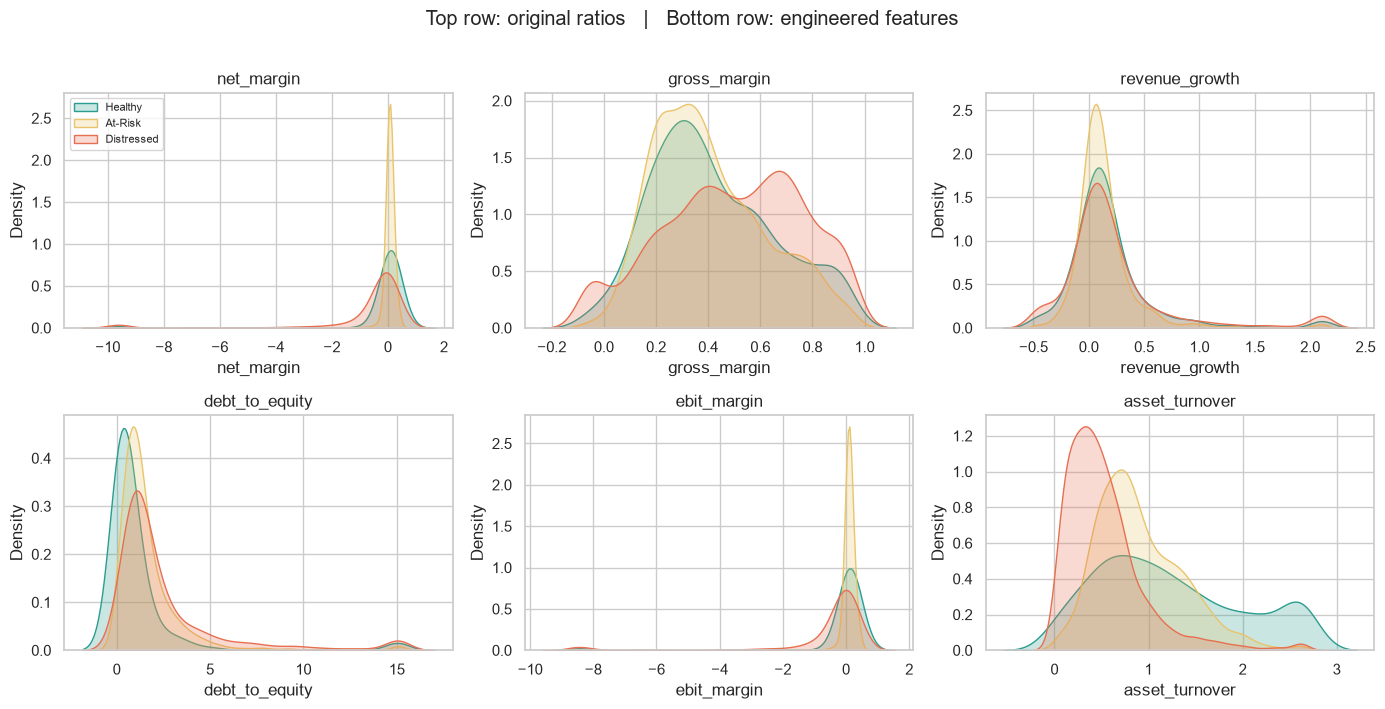

In [ ]:
## 9. Exploratory check — do the engineered features separate the classes?

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
order = ["Healthy", "At-Risk", "Distressed"]
palette = {"Healthy": "#2a9d8f", "At-Risk": "#e9c46a", "Distressed": "#e76f51"}

for ax, col in zip(axes.ravel(),
                   ["net_margin", "gross_margin", "revenue_growth",
                    "debt_to_equity", "ebit_margin", "asset_turnover"]):
    s = train_df[col].clip(train_df[col].quantile(.02), train_df[col].quantile(.98))
    for lab in order:
        sns.kdeplot(s[train_df.label == lab], ax=ax, label=lab,
                    color=palette[lab], fill=True, alpha=.25)
    ax.set_title(col)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Top row: original ratios   |   Bottom row: engineered features", y=1.01)
fig.tight_layout()
plt.savefig(C.FIGURES_DIR / "feature_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
cmp = pd.concat([
    train_df.groupby("label")[["gross_margin", "net_margin"]].median(),
    train_df.groupby("label")[["debt_to_equity", "ebit_margin",
                               "current_ratio", "asset_turnover"]].median()
], axis=1).round(3)
print("Median feature value per class (train fold)")
print(cmp.to_string())

Median feature value per class (train fold)
            gross_margin  net_margin  debt_to_equity  ebit_margin  current_ratio  asset_turnover
label                                                                                           
At-Risk            0.362       0.060           1.152        0.091          1.805           0.817
Distressed         0.510      -0.094           1.280       -0.039          1.583           0.439
Healthy            0.377       0.085           0.375        0.104          3.238           1.067
